## Building Chatbot with Multiple Tools using LangGraph

#### AIM-> Creating a chatbot with tool capabilities from **ARXIV**, **WIKIPEDIA** and some functions

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper 

In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper= api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper= api_wrapper_wiki)
print(wiki.name)

wikipedia


In [5]:
wiki.invoke("Hunter X Hunter")

'Page: Hunter × Hunter\nSummary: Hunter × Hunter (pronounced "hunter hunter") is a Japanese manga series written and illustrated by Yoshihiro Togashi. It has been serialized in Shueisha\'s shōnen manga magazine Weekly Shōnen Jump since March 1998, although the manga has frequently gone on extended hiatuses since 2006. Its chapters have been collected in 38 tankōbon volumes as of September 2024. The manga has been licensed for English release in North America by Viz Media.\nThe story focuses on a you'

In [6]:
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = "true"
os.environ['LANGCHAIN_PROJECT'] = "Chatbot with MultiTools"

In [7]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()
tavily.invoke('Provide me the recent AI news')

C:\Users\singh\AppData\Local\Temp\ipykernel_1304\1147393803.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


[{'title': 'March 2026 AI News Roundup: Breakthroughs and the Fights, Forecasts, and Fears - Peterson Technology Partners',
  'url': 'https://www.ptechpartners.com/2026/04/07/march-2026-ai-news-roundup-breakthroughs-and-the-fights-forecasts-and-fears/',
  'content': 'With 80% of Claude Code’s $2.5 billion in annual revenue coming from enterprise adoption, this leak is not only a security risk, but also a big chance for rivals to catch up.  \n\n(Among the reveals, a “Self-Healing Memory” system, the autonomous “KAIROS” background agent, and “Undercover Mode,” which appears to be used to submit to open-source repositories without admitting that it’s coming from Claude.) \n\nAnd according to the Pragmatic Engineer’s Gergely Orosz, some repositories had even rewritten the code entirely in Python within the dayin a bid to stay online (longer at least), showing the new ways AI changes even software copyright enforcement.  \n\nWhat else happened in AI in March 2026? [...] Alibaba’s Qwen AI te

In [8]:
tavily.invoke('Today IPL match')

[{'title': "MI Vs LSG, IPL 2026: Is Hardik Pandya Playing Today's Indian Premier League 2026 Match? | Yardbarker",
  'url': 'https://www.yardbarker.com/cricket/articles/mi_vs_lsg_ipl_2026_is_hardik_pandya_playing_todays_indian_premier_league_2026_match/s1_17771_43804419',
  'content': "For Mumbai Indians, this match feels like a final stand. After a disastrous run that has seen them lose seven of their last eight games, a defeat tonight would effectively end their journey in the tournament. The team has lacked their usual consistency, hampered by injuries to key players and an inability to find rhythm as a unit.\n\nTheir campaign has been a shadow of their championship pedigree, with only two wins to show from nine outings, the side currently sits in ninth place with a dismal net run rate of -0.803.\n\nA major point of concern has been the form of skipper Hardik Pandya. The all-rounder has endured a challenging campaign, managing only 146 runs in eight appearances. His impact with the 

In [9]:
## Combine all the tools in a list
tools = [arxiv, wiki, tavily]

from langchain_groq import ChatGroq

llm = ChatGroq(model= os.getenv('GROQ_MODEL'), api_key= os.getenv('GROQ_API_KEY'))
LLM = llm.bind_tools(tools=tools)

In [11]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

LLM.invoke([HumanMessage(content= f"What is Recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest AI news 2024'},
  'id': 'fc_13a0e14d-72bb-4bdc-ba9f-6f8a4aa2ac0d',
  'type': 'tool_call'}]

In [13]:
## State Schema
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated
from dataclasses import dataclass

@dataclass
class State:
    messages: Annotated[list[AnyMessage], add_messages]

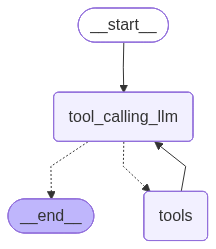

In [14]:
## Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

## Node Defination
def tool_calling_llm(state: State):
    return {"messages": [LLM.invoke(state.messages)]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
result = graph.invoke({"messages": HumanMessage(content="What is Jujutsu Kaisen")})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is Jujutsu Kaisen
================================== Ai Message ==================================

**Jujutsu Kaisen** (呪術廻戦, *Jujutsu Kaisen*) is a Japanese manga series written and illustrated by **Gege Akutami**. It debuted in Shueisha’s *Weekly Shōnen Jump* on March 5 2018 and quickly became one of the magazine’s flagship titles. The series has since been adapted into a highly successful anime, several movies, spin‑off manga, light novels, video games, and a wide range of merchandise.

---

## Premise

The story is set in a world where “cursed energy” – the negative emotions of humanity – manifests as malevolent spirits called **Curses**. Certain people can manipulate this energy and become **Jujutsu Sorcerers**, whose job is to protect ordinary people by exorcising curses.

### Main Plot

- **Yuji Itadori**, a physically gifted high‑schooler, swallows a finger of the powerful Curse **Ryōmen Suku

In [17]:
result = graph.invoke({"messages": HumanMessage(content="What is attention is all you need?")})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is attention is all you need?
================================== Ai Message ==================================

**“Attention Is All You Need”** is the title of a landmark 2017 research paper (Vaswani et al., *NeurIPS 2017*) that introduced the **Transformer** model—a new neural‑network architecture for sequence‑to‑sequence tasks such as machine translation, summarization, and language modeling.  

Below is a concise, self‑contained overview of the paper’s motivation, core ideas, architecture, and impact.

---

## 1. Why a new architecture?

| Issue with previous models | How the Transformer solves it |
|----------------------------|--------------------------------|
| **Recurrent Neural Networks (RNNs) / LSTMs** process tokens sequentially, making training *slow* (cannot be parallelized) and *hard* to capture long‑range dependencies because of vanishing gradients. | **Self‑attention** allows every tok

In [20]:
result = graph.invoke({"messages": HumanMessage(content="Today's News")})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Today's News
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_442aa5a8-42ed-439e-ba80-aca0ef6c8a9f)
 Call ID: fc_442aa5a8-42ed-439e-ba80-aca0ef6c8a9f
  Args:
    query: latest news today
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Fox News - Breaking News Updates | Latest News Headlines | Photos & News Videos", "url": "https://www.foxnews.com/", "content": "### Tens of millions of taxpayers may be owed IRS refunds from COVID-era\n\n### Fidelity, Vanguard reportedly pause SPLC grants after federal fraud charges\n\nThe Southern Poverty Law Center (SPLC) building stands on 3rd March 2020 in Montgomery, Alabama. - Fox News\n\n### Credit expert warns borrowers about the 'American drain' as new mortgage scoring models take effect\n\nChanges are coming to